# M5A6 - Detecção de Faixas para Veículos Autônomos

Na prática de hoje vamos refinar um modelo para a tarefa de detecção de faixas para veículos autônomos.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision datasets tqdm ipywidgets

Importar as bibliotecas

In [2]:
import datasets
import torch
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/danjacobellis/bdd100k_15frames_eomt

In [3]:
# Baixando dataset.
# Esse dataset possui apenas split de treino.
dataset = datasets.load_dataset("danjacobellis/bdd100k_15frames_eomt", split="validation")

# Split dataset.
split_ds = dataset.train_test_split(test_size=0.1, seed=42)

# Pegar splits de dados.
train_dataset = split_ds["train"]
test_dataset = split_ds["test"]


# Transformações dos dados.
def transforms(examples):
    #Transformações das imagens.
    image_transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224), # Common input size for ImageNet models
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    target_transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224), # Common input size for ImageNet models
    ])


    for i in range(14):
        images = [image_transforms(image) for image in examples[f"original_{i}"]] # Aplica transformações nas imagens
        targets = [target_transforms(np.array(image) == 0) for image in examples[f"label_{i}"]]

    # Retorna dicionário compatível com dataloader.
    return {"image": images, "target": targets}



def collate_fn(batch):
    # Organiza o retorno do dataloader.
    images = torch.stack([item["image"] for item in batch])
    targets = torch.stack([item["target"] for item in batch]).squeeze().long()
    return images, targets

train_dataset =  train_dataset.with_transform(transforms)
test_dataset = test_dataset.with_transform(transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

## Refinar Modelo

Na prática de hoje iremos refinar o modelo **Fully Convolutional** disponível no torchvision.

In [4]:
# Definindo dispositivo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carregando modelo.
model = torchvision.models.segmentation.fcn_resnet101(weights="DEFAULT")


num_classes = 2 # apenas 2 classes.
in_features = 2048 # Valor do modelo.
model.classifier = torchvision.models.segmentation.fcn.FCNHead(in_features, num_classes) # substitui a última camada do modelo.

model.to(device) # Colocando modelo no dispositivo.

# Definindo o otimizador.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

# class_weight = torch.tensor([0.1, 0.9]).to(device)
criterion = torch.nn.CrossEntropyLoss()

# Treinamento do modelo
model.train()
epochs = 1 # Alterar para treinar mais epocas.
for epoch in range(epochs):
    iteration = 0
    for images, targets in tqdm(train_loader):
        # Muda o dispostivo de processamento dos dados.
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        loss = criterion(outputs["out"], targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if iteration % 30 == 0:
            print(f"Total loss: {loss.item()}")
        iteration += 1

/home/joaoferreira/trilha_visao_computacional/.env-trilha-vc/lib/python3.10/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  0%|          | 0/113 [00:00<?, ?it/s]

Total loss: 0.7537094950675964
Total loss: 0.5057350397109985
Total loss: 0.3504736125469208
Total loss: 0.3008073568344116


## Validar Modelo

Agora vamos testar o nosso modelo.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.035294096589088386..1.0000000236034394].


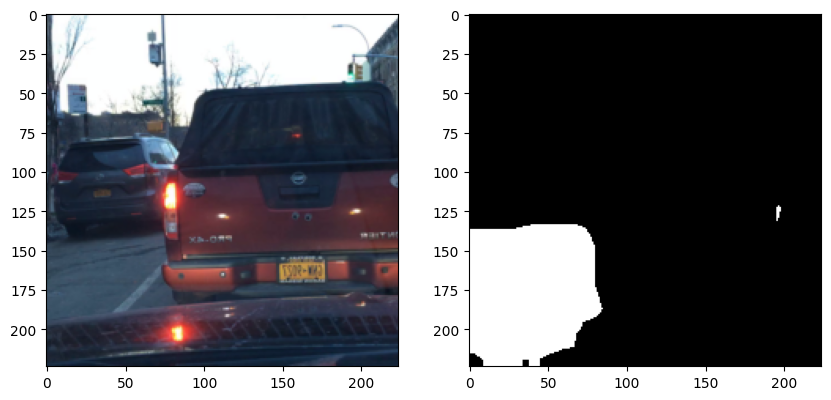

In [13]:
def decode_segmap(image, cls=1):
    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    idx = image == cls
    r[idx] = 255
    g[idx] = 255
    b[idx] = 255

    rgb = np.stack([r, g, b], axis=2)
    return rgb

# Tamanho do dataset de treino.
len_test_data = len(test_dataset)

# Sortear amostra do dataset de teste.
idx = torch.randint(len_test_data, (1,))

# Modelo em modo de avaliação.
model.eval()
with torch.no_grad():
    image = torch.stack(test_dataset[idx]["image"])

    # Coloca as imagens no dispositivo e passa pelo modelo. 
    image = image.to(device)
    output = model(image)

output = torch.argmax(output["out"].squeeze(), dim=0).detach().cpu().numpy() # Pegando a maior predição de classe para cada pixel.

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
_, ax = plt.subplots(1, 2,  figsize=(10, 5))
ax[0].imshow((image.detach().cpu()[0].permute(1,2,0).numpy()*std)+mean)
ax[1].imshow(decode_segmap(output, cls=1))
plt.show()


## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.pytorch.org/vision/main/models/fcn.html
- https://huggingface.co/datasets/danjacobellis/bdd100k_15frames_eomt
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar a base de dados e veja se o modelo continua funcionando?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, batch e resolução da imagens e veja como isso altera os resultados.